<a href="https://colab.research.google.com/github/GyeongHub/ESAA-OB/blob/main/week12_0523_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*0523(금) 12주차 과제*\
*딥러닝 파이토치 교과서 5장 합성곱 신경망1 - 03  p.200-229*

# 5.3 전이 학습

충분히 큰 데이터셋을 얻는 것은 어려움 -> **전이 학습** 도입으로 해결

- 전이학습이란? \
아주 큰 데이터셋을 써서 훈련된 모델(네트워크)의 가중치 -> 해결하려는 과제에 맞게 보정해서 사용하는 것. \
결과적으로 비교적 적은 수의 데이터를 가지고도 우리가 원하는 과제를 해결할 수 있음.

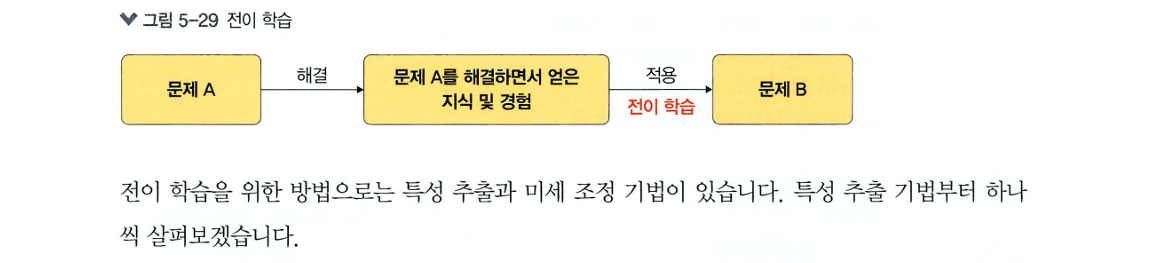

- 전이 학습을 위한 방법
    - 특성 추출 기법
    - 미세 조정 기법

---

## 5.3.1 특성 추출 기법

**특성 추출** \
이미지넷 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만듦. \
즉, 마지막 완전연결층(카테고리를 결정하는 부분)만 학습하고 나머지 계층은 학습X

---

**특성 추출의 구성** \
- 합성곱층: 합성곱층, 풀링층으로 구성
- 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층(가중치 고정)에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킴.


---

**사용 가능한 이미지 분류 모델** \
- Xception
- Inception V3
- ResNet50
- VGG16
- VGG19
- MobileNet

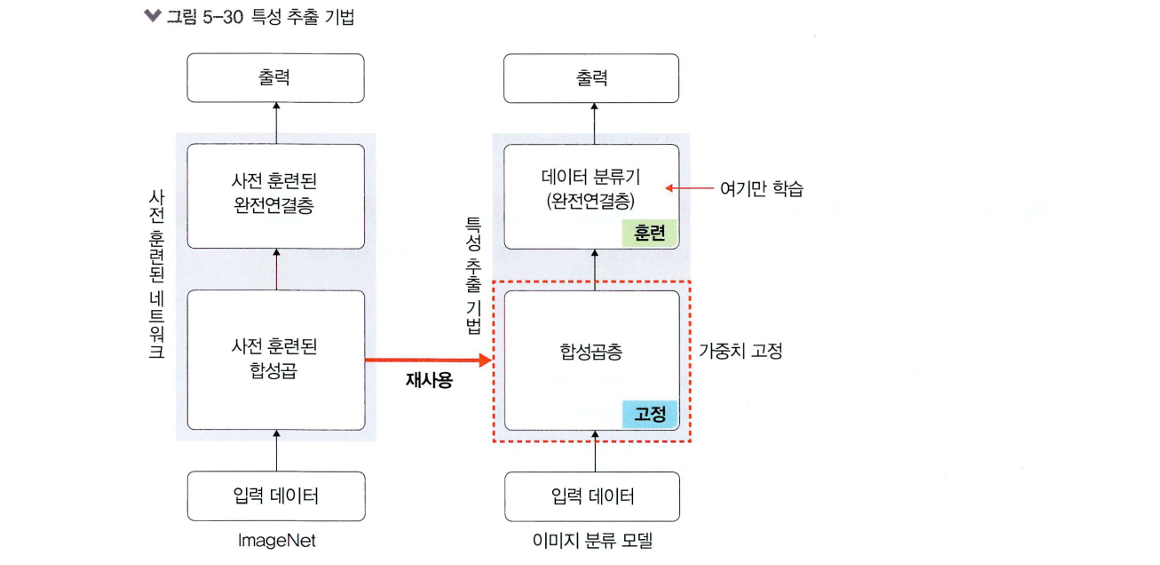

In [1]:
pip install opencv-python

In [2]:
# 코드 5-12 라이브러리 호출

import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
# 1. 저장소 전체를 clone
!git clone https://github.com/gilbutITbook/080289.git

# 2. 작업 디렉토리를 해당 폴더로 이동
%cd 080289/chap05/data/catanddog/

# 3. 파일 목록 확인
!ls

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 2278 (delta 4), reused 27 (delta 3), pack-reused 2246 (from 1)
Receiving objects: 100% (2278/2278), 330.30 MiB | 18.84 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.
/content/080289/chap05/data/catanddog
test  train


In [4]:
# 코드 5-13 이미지 데이터 전처리 방법 정의

data_path = '/content/080289/chap05/data/catanddog/train'


transform = transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ])      # (1)

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)           # (2)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle = True
)           # (3)

print(len(train_dataset))

385


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


>  (1) torchvision.transfrom \
이미지 데이터를 변환하여 모델(네트워크)의 입력으로 사용할 수 있게 변환해 줌.

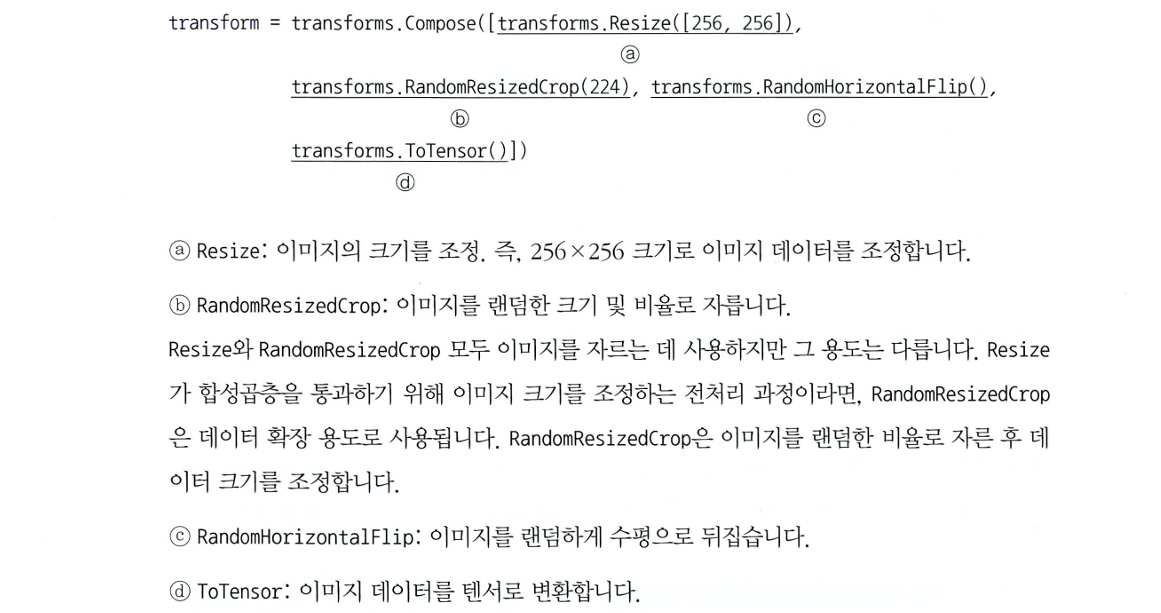

> (2) datasets.lmageFolder \
데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(transform) (혹은 전처리)을 정의

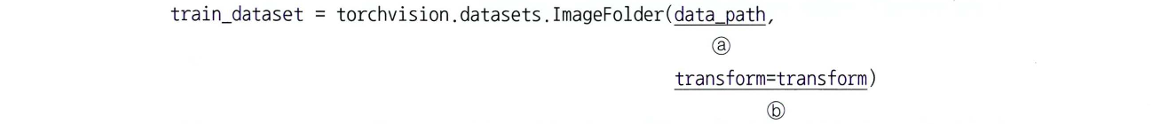

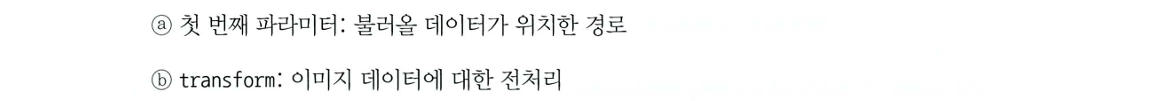

> (3) 데이터로더 \
데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당하는데, 이때 한 번에 불러올 데이터양을 결정하는 batch size를 지정함. 또한, 추가적으로 데이터를 무작위로 섞을(shuff1e) 것인지도 설정함.

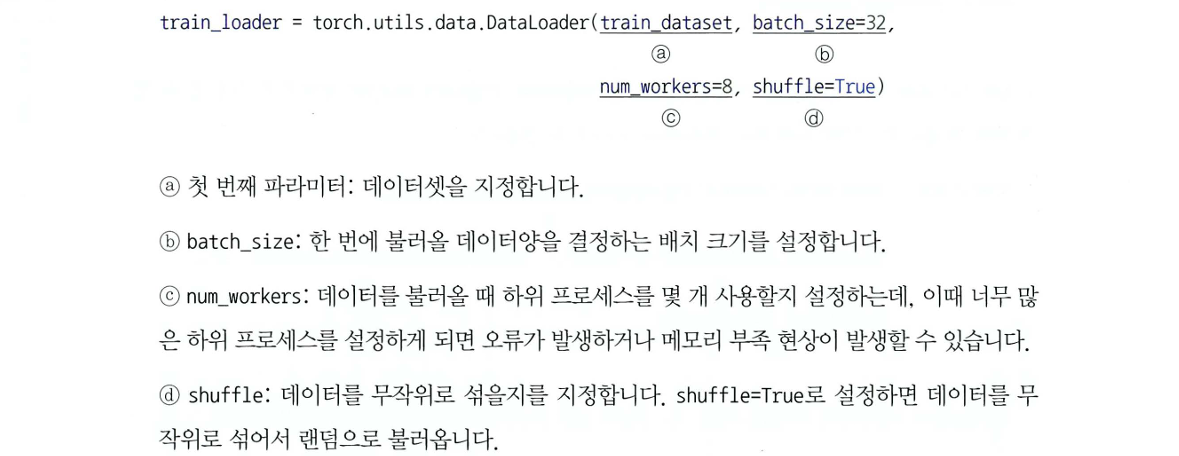

---

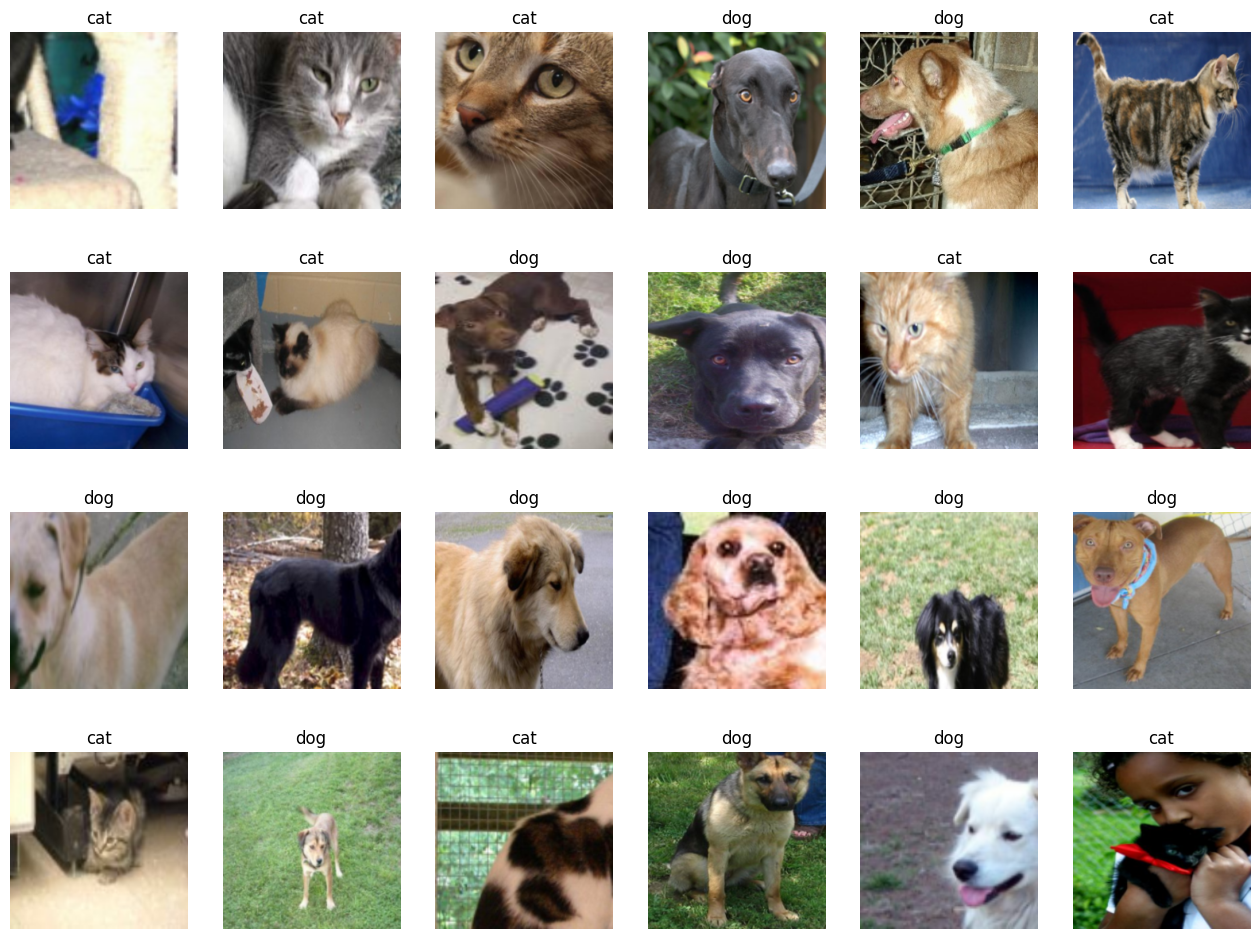

In [5]:
# 코드 5-14 학습에 사용될 이미지 출력

import numpy as np
samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))
for i in range(24):
    a = fig.add_subplot(4,6,i+1)
    a.set_title(classes[labels[i].item()])
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

> (1) 반복자 \
    반복자(iterator, for)를 사용하려면 iter()와 next()가 필요함.  iter()로 반복자를 구하고 그 반복자를 next()에 전달하여 차례대로 꺼낼 수 있음.

> (2)  np.transpose \
 다음 그림과 같이 행과 열을 바꿈으로써 행렬의 차원을 바꿈

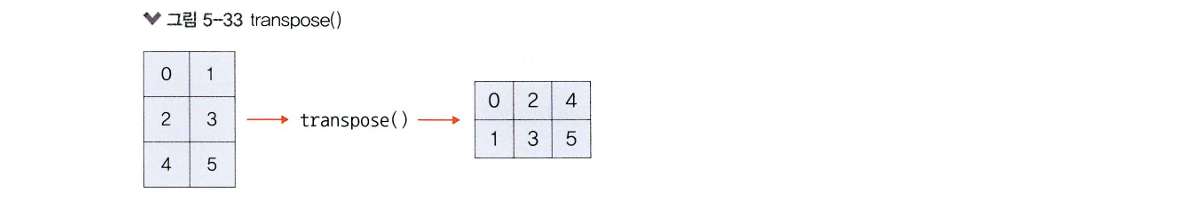

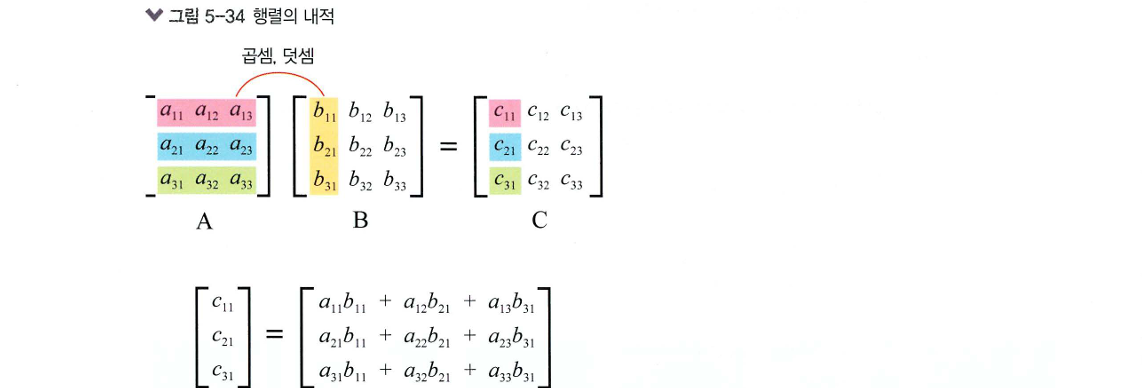

- print(samples.shape)
    - torch.Size([32, 3, 224, 224])
- np.transpose(samples[i].numpy(), (1,2,0))
    - (224, 224, 3)로 변환됨

In [6]:
# transpose 예시

exam = np.arange(24).reshape(2, 3, 4)
exam

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [7]:
np.transpose(exam, (2,1,0)) # (2,3,4) -> (4,3,2)

array([[[ 0, 12],
        [ 4, 16],
        [ 8, 20]],

       [[ 1, 13],
        [ 5, 17],
        [ 9, 21]],

       [[ 2, 14],
        [ 6, 18],
        [10, 22]],

       [[ 3, 15],
        [ 7, 19],
        [11, 23]]])

---

In [8]:
# 코드 5-15 사전 훈련된 모델 내려받기

resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


In [9]:
# 코드 5-16 사전 훈련된 모델의 파라미터 학습 유무 지정

def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

set_parameter_requires_grad(resnet18)

> **`param.requires_grad = False`** \
역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음. \
모델의 일부(합성곱층, 풀링층)를 고정하고 나머지를 학습하고자 할 때 `requires_grad = False`로 설정.

In [10]:
# 코드 5-17 ResNet18에 완전연결층 추가:  개와 고양이 클래스를 분류하는 용도

resnet18.fc = nn.Linear(512, 2) # 2는 클래스가 2개임을 의미

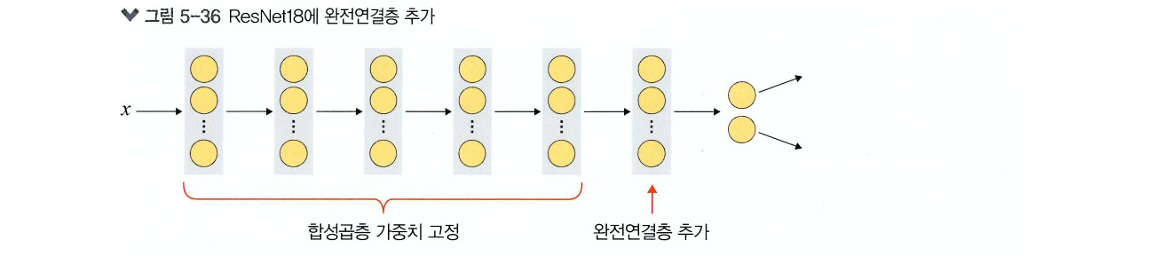

In [11]:
# 코드 5-18 모델의 파라미터 값 확인

for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[-0.0374, -0.0426, -0.0373,  ...,  0.0095, -0.0073,  0.0424],
        [-0.0410,  0.0325,  0.0030,  ...,  0.0422, -0.0137,  0.0194]])
fc.bias tensor([-0.0070, -0.0038])


-> 파라미터는 weight와 bias가 사용되고 있음.

In [12]:
# 코드 5-19 모델 객체 생성 및 손실 함수 정의

model = models.resnet18(pretrained = True)

for param in model.parameters():
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

-> 내려받은 ResNet18 모델의 마지막에 완전연결층을 추가한 모델을 보여줌

In [13]:
# 코드 5-20 모델 학습을 위한 함수 생성

def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders.dataset)
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('/content/080289/chap05/data/catanddog/', '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history, loss_history

In [14]:
# 코드 5-21 파라미터 학습 결과를 옵티마이저에 전달

params_to_update = []
for name,param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [15]:
# 코드 5-22 모델 학습

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.5395 Acc: 0.7143

Epoch 1/12
----------
Loss: 0.4082 Acc: 0.8364

Epoch 2/12
----------
Loss: 0.3538 Acc: 0.8338

Epoch 3/12
----------
Loss: 0.2800 Acc: 0.8961

Epoch 4/12
----------
Loss: 0.2481 Acc: 0.9169

Epoch 5/12
----------
Loss: 0.2061 Acc: 0.9273

Epoch 6/12
----------
Loss: 0.2300 Acc: 0.9013

Epoch 7/12
----------
Loss: 0.2160 Acc: 0.9091

Epoch 8/12
----------
Loss: 0.2360 Acc: 0.8987

Epoch 9/12
----------
Loss: 0.2125 Acc: 0.9195

Epoch 10/12
----------
Loss: 0.2543 Acc: 0.8753

Epoch 11/12
----------
Loss: 0.1730 Acc: 0.9299

Epoch 12/12
----------
Loss: 0.2267 Acc: 0.8961

Training complete in 10m 7s
Best Acc: 0.929870


-> 모델 학습에 대한 결과: 약 93%로 상당히 높은 정확도

-> 전달되는 파라미터: 모델, 학습 데이터, 손실 함수, 옵티마이저, 장치(CPU 또는 GPU)

In [16]:
# 코드 5-23 테스트 데이터 호출 및 전처리

test_path = '/content/080289/chap05/data/catanddog/test'

transform = transforms.Compose(
                [
                    transforms.Resize(224),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


-> 테스트용 데이터

In [17]:
# 코드 5-24 테스트 데이터 평가 함수 생성

def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('../chap05/data/catanddog/' + '*.pth')
    saved_models.sort()
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1
            preds[preds < 0.5] = 0
            running_corrects += preds.eq(labels.cpu()).int().sum()

        epoch_acc = running_corrects.double() / len(dataloaders.dataset)
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history

> **`glob`** \
현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용함.

> **`torch.max`**\
주어진 텐서 배열의 최댓값이 들어 있는 index를 반환하는 함수

> **`preds.eq(labels)`**\
preds 배열과 labels가 일치하는지 검사히는 용도로 사용함.

> `**.sum()**`\
모델의 예측 결과와 정답(레이블)이 일치히는 것들의 개수 합을 숫자로 출력함.

In [18]:
# 코드 5-25 테스트 데이터를 평가 함수에 적용

val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model []
Validation complete in 0m 0s
Best Acc: 0.000000


-> 테스트 데이터 역시 94% 정도의 높은 정확도를 보임.

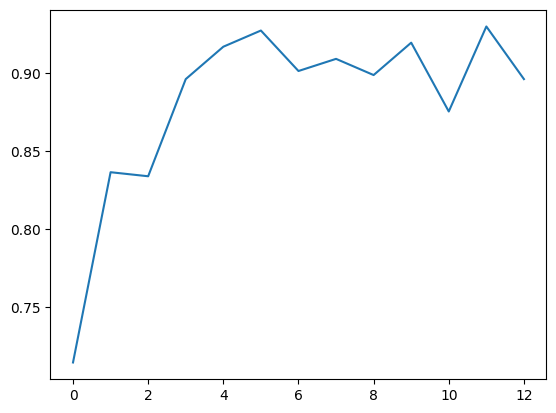

In [19]:
# 코드 5-26 훈련과 테스트 데이터의 정확도를 그래프로 확인

plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

-> 훈련과 테스트 데이터 모두 에포크가 진행될수록 정확도가 높아지면서 100%에 가까워짐

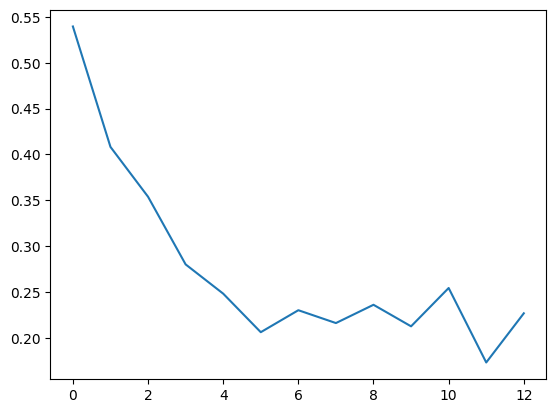

In [20]:
# 코드 5-27 훈련 데이터의 오차에 대한 그래프 확인

plt.plot(train_loss_hist)
plt.show()

-> 에포크가 진행될 수록 오차가 낮아지고 있기 때문에 학습이 잘됨.

In [21]:
# 코드 5-28 예측 이미지 출력을 위한 전처리 함수

def im_convert(tensor):
    image=tensor.clone().detach().numpy()
    image=image.transpose(1,2,0)
    image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
    image=image.clip(0,1)
    return image

> **`tensor.clone()`**\
기존 텐서의 내용을 복사한 텐서를 생성하겠다는 의미

> **`detach()`**\
기존 텐서에서 기울기가 전파되지 않는 텐서

    즉 tensor.clone().detach()는 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미

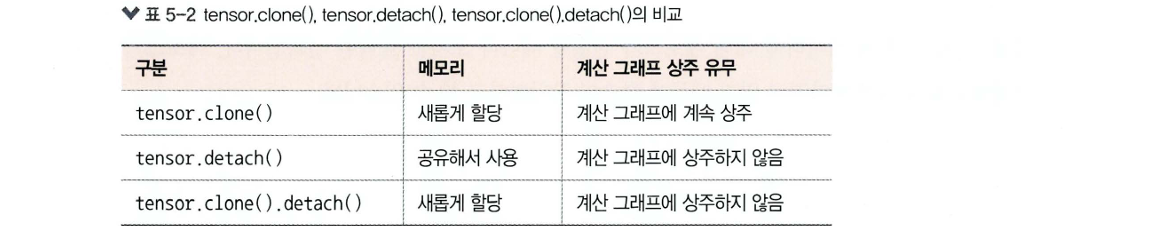

> **`clip()`**\
입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시키기 위해 사용함. \
즉, image.clip(0, 1)은 image 데이터를 0과 1 사이의 값으로 제한하겠다는 의미

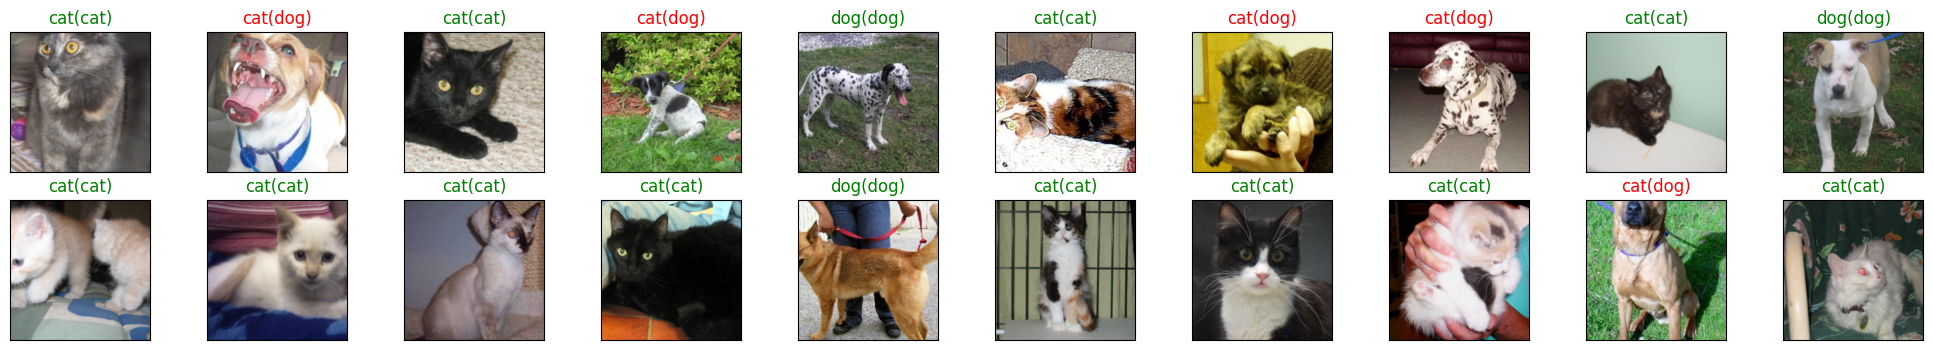

<Figure size 640x480 with 0 Axes>

In [24]:
# 코드 5-29 개와 고양이 예측 결과 출력

classes = {0:'cat', 1:'dog'}

dataiter=iter(test_loader)
images,labels=next(dataiter)
output=model(images)
_,preds=torch.max(output,1)

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
    plt.imshow(im_convert(images[idx]))
    a.set_title(classes[labels[i].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

-> 개와 고양이에 대한 예측 결과.
초록색은 개와 고양이를 정확하게, 빨간색은 예측이 잘못되었음을 의미함.

> **`add_subplot`**
한 화면에 여러 개의 이미지를 담기 위해 사용함.

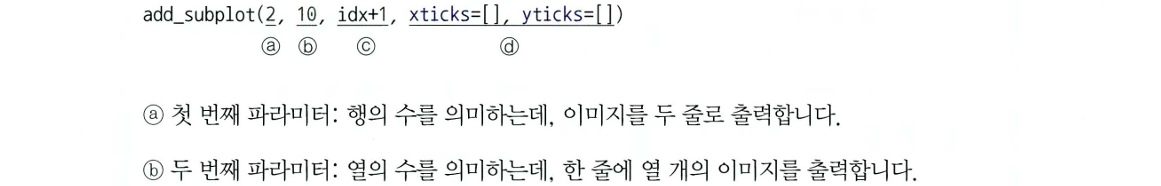

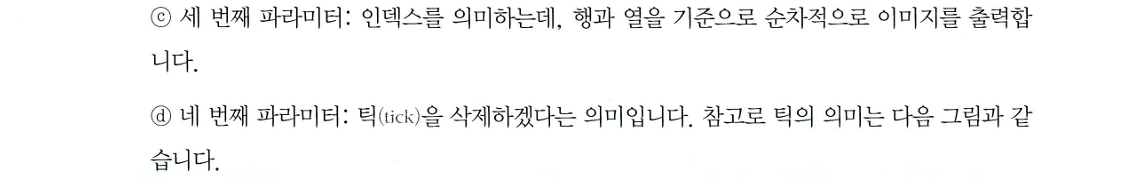

> **`classes[preds[idx].item()]`**\
preds[idx].item() 값이 classes로 정의된 0과 1 중 어떤 값을 갖는지 판별하겠다는 의미.\
classes[preds[idx].item()] 값이 0이면 고양이, 1이면 개로 출력됨.

> **`plt.subplots_adjust`**\
Figure 안에서 서브플롯(suhpJot)의 위치를 조정할 때 사용함.\
left, bottom, right, top으로 이미지 위치를 조정함. \
hspace와 wspace를 사용해서 서브플롯 간의 간격(너비와 높이의 비율)을 조정함.

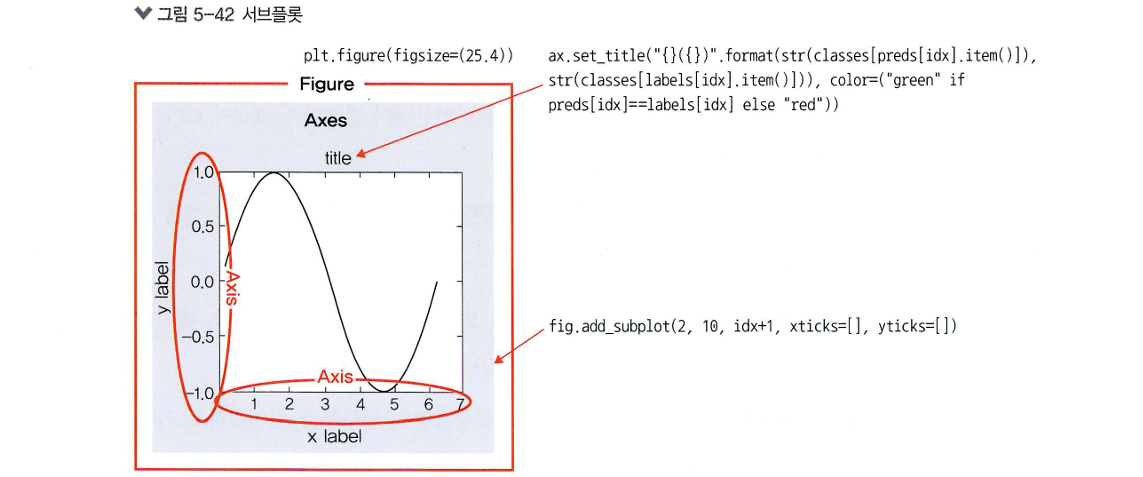

---

## 5.3.2 미세 조정 기법

**미세 조정 기법**
- 특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식.
- 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학습시키는 것.
- 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모델의 파라미터를 조정하는 기법

**미세 조정 기법의 전략**
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우: 모델 전체를 재학습.
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우: 합성곱층의 뒷부분(완전연결층과 가까운 부분)과 데이터 분류기를 학습.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우: 합성곱층의 일부분과 데이터 분류기를 학습.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우: 데이터 분류기만 학습.

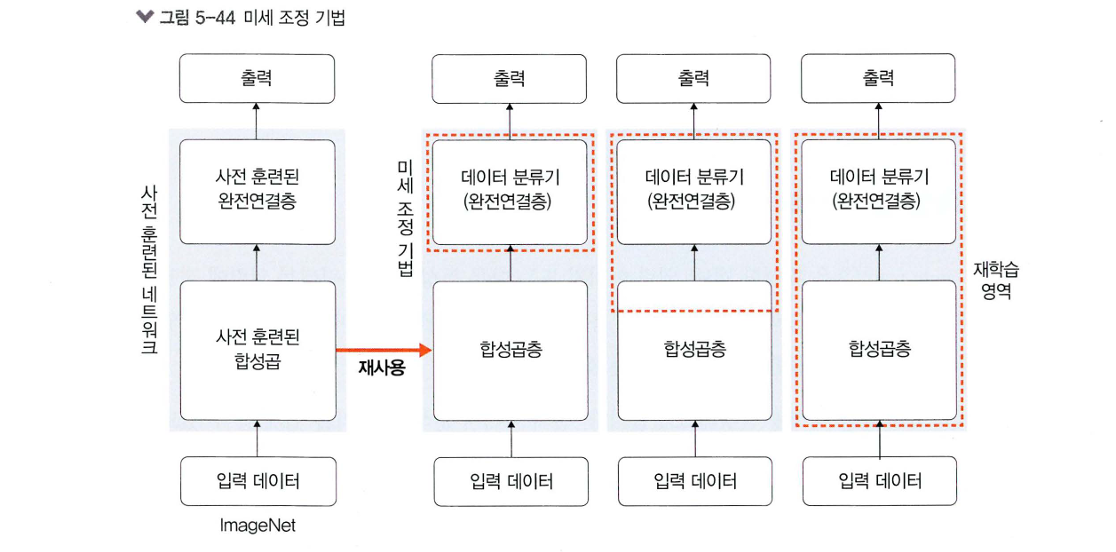